# AquaPlant — Phase D: Locked Test Evaluation

This notebook performs the **final locked Test-set evaluation** for the two models selected in Phase C:

- **ResNet50**
- **EfficientNet-B0**

It evaluates both the frozen and fine-tuned checkpoints, so the notebook can also report the fine-tuning ablation.

**Important:** This notebook performs **no training and no tuning**. The locked Test set is used only for final reporting.

Expected Kaggle inputs:
- Aqua Plant Final Dataset
- ResNet50 artifacts
- EfficientNet-B0 artifacts

In [19]:
# ============================================================
# CELL 1 — ENVIRONMENT SETUP
# ============================================================

import os
import random
import time
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torchvision.models import resnet50, efficientnet_b0
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 14

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("=" * 72)
print("PHASE D — LOCKED TEST EVALUATION")
print("=" * 72)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("\nKaggle inputs:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

print("\n✅ CELL 1 COMPLETE")


PHASE D — LOCKED TEST EVALUATION
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4

Kaggle inputs:
 - datasets

✅ CELL 1 COMPLETE


In [20]:
# ============================================================
# CELL 2 — FIND LOCKED TEST SET + MODEL ARTIFACTS
# Supports BOTH:
#   A) direct .pth files inside Kaggle inputs
#   B) artifact .zip files that still need extraction
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)

def count_images_recursive(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += sum(
            1 for file in files
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )
    return total

def count_direct_folders(folder):
    try:
        return len([
            d for d in os.listdir(folder)
            if os.path.isdir(os.path.join(folder, d))
        ])
    except Exception:
        return 0

def search_all_files(root="/kaggle/input"):
    found = []
    for current_root, dirs, files in os.walk(root):
        for file in files:
            found.append(os.path.join(current_root, file))
    return found

ALL_INPUT_FILES = search_all_files()

# -------------------------
# Find locked Test folder
# -------------------------
TEST_DIR = None

for root, dirs, files in os.walk("/kaggle/input"):
    if count_direct_folders(root) == 14:
        n_images = count_images_recursive(root)
        if n_images == 157:
            TEST_DIR = root
            break

assert TEST_DIR is not None, "❌ Locked Test folder with 157 images was not found."
assert count_images_recursive(TEST_DIR) == 157

# -------------------------
# Helper: checkpoint search
# -------------------------
def find_pth(required_words):
    required_words = [w.lower() for w in required_words]
    matches = []

    for path in ALL_INPUT_FILES:
        name = os.path.basename(path).lower()

        if not name.endswith(".pth"):
            continue

        if all(word in name for word in required_words):
            matches.append(path)

    return matches[0] if matches else None

# Direct checkpoint detection
RESNET_FROZEN_PTH = find_pth(["resnet50", "stage1", "best"])
RESNET_FINETUNED_PTH = find_pth(["resnet50", "finetuned", "best"])
EFFNET_FROZEN_PTH = find_pth(["efficientnet", "frozen", "best"])
EFFNET_FINETUNED_PTH = find_pth(["efficientnet", "finetuned", "best"])

# If any checkpoint is missing, look for artifact ZIPs and extract them.
NEED_EXTRACTION = any(x is None for x in [
    RESNET_FROZEN_PTH,
    RESNET_FINETUNED_PTH,
    EFFNET_FROZEN_PTH,
    EFFNET_FINETUNED_PTH
])

if NEED_EXTRACTION:
    EXTRACT_ROOT = "/kaggle/working/phaseD_extracted_artifacts"
    os.makedirs(EXTRACT_ROOT, exist_ok=True)

    zip_candidates = [
        p for p in ALL_INPUT_FILES
        if p.lower().endswith(".zip")
        and (
            "resnet" in os.path.basename(p).lower()
            or "efficientnet" in os.path.basename(p).lower()
        )
    ]

    for zip_path in zip_candidates:
        target = os.path.join(
            EXTRACT_ROOT,
            Path(zip_path).stem
        )
        os.makedirs(target, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(target)

    # Search extracted files too.
    for current_root, dirs, files in os.walk(EXTRACT_ROOT):
        for file in files:
            ALL_INPUT_FILES.append(os.path.join(current_root, file))

    RESNET_FROZEN_PTH = RESNET_FROZEN_PTH or find_pth(["resnet50", "stage1", "best"])
    RESNET_FINETUNED_PTH = RESNET_FINETUNED_PTH or find_pth(["resnet50", "finetuned", "best"])
    EFFNET_FROZEN_PTH = EFFNET_FROZEN_PTH or find_pth(["efficientnet", "frozen", "best"])
    EFFNET_FINETUNED_PTH = EFFNET_FINETUNED_PTH or find_pth(["efficientnet", "finetuned", "best"])

print("=" * 72)
print("PHASE D RESOURCE DETECTION")
print("=" * 72)

print("Locked Test:")
print(TEST_DIR)

print("\nResNet50 Frozen:")
print(RESNET_FROZEN_PTH)

print("\nResNet50 Fine-tuned:")
print(RESNET_FINETUNED_PTH)

print("\nEfficientNet-B0 Frozen:")
print(EFFNET_FROZEN_PTH)

print("\nEfficientNet-B0 Fine-tuned:")
print(EFFNET_FINETUNED_PTH)

assert RESNET_FROZEN_PTH is not None, "❌ ResNet50 Stage-1 checkpoint not found."
assert RESNET_FINETUNED_PTH is not None, "❌ ResNet50 fine-tuned checkpoint not found."
assert EFFNET_FROZEN_PTH is not None, "❌ EfficientNet frozen checkpoint not found."
assert EFFNET_FINETUNED_PTH is not None, "❌ EfficientNet fine-tuned checkpoint not found."

print("\n" + "=" * 72)
print("✅ ALL PHASE D RESOURCES FOUND")
print("=" * 72)
print("✅ Locked Test = 157 images")
print("✅ ResNet50 frozen checkpoint")
print("✅ ResNet50 fine-tuned checkpoint")
print("✅ EfficientNet-B0 frozen checkpoint")
print("✅ EfficientNet-B0 fine-tuned checkpoint")


PHASE D RESOURCE DETECTION
Locked Test:
/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test

ResNet50 Frozen:
/kaggle/input/datasets/srabondcosta/resnet50/resnet50_stage1_best.pth

ResNet50 Fine-tuned:
/kaggle/input/datasets/srabondcosta/resnet50/resnet50_finetuned_best.pth

EfficientNet-B0 Frozen:
/kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_frozen_best.pth

EfficientNet-B0 Fine-tuned:
/kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_finetuned_best.pth

✅ ALL PHASE D RESOURCES FOUND
✅ Locked Test = 157 images
✅ ResNet50 frozen checkpoint
✅ ResNet50 fine-tuned checkpoint
✅ EfficientNet-B0 frozen checkpoint
✅ EfficientNet-B0 fine-tuned checkpoint


In [21]:
# ============================================================
# CELL 3 — LOCKED TEST DATALOADER
# Exact deterministic Phase-B evaluation preprocessing
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

CLASS_NAMES = test_dataset.classes

print("=" * 72)
print("LOCKED TEST SET")
print("=" * 72)
print("Test images :", len(test_dataset))
print("Classes     :", len(CLASS_NAMES))

print("\nClass mapping:")
for cls, idx in test_dataset.class_to_idx.items():
    print(f"{idx:2d} -> {cls}")

assert len(test_dataset) == 157
assert len(CLASS_NAMES) == 14

# Save class mapping for reproducibility.
with open("/kaggle/working/phaseD_class_mapping.json", "w") as f:
    json.dump(test_dataset.class_to_idx, f, indent=2)

print("\n🔒 TEST SET IS NOW LOADED FOR FINAL EVALUATION")
print("✅ NO TRAINING / TUNING WILL BE PERFORMED")


LOCKED TEST SET
Test images : 157
Classes     : 14

Class mapping:
 0 -> Class_10_lippia_alba
 1 -> Class_11_marsilea_minuta
 2 -> Class_12_duck_weeds
 3 -> Class_13_topapana
 4 -> Class_14_kachuripana
 5 -> Class_1_water_iris
 6 -> Class_2_pistia_stratiotes
 7 -> Class_3_lily_leaf
 8 -> Class_4_lotus-leaf
 9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

🔒 TEST SET IS NOW LOADED FOR FINAL EVALUATION
✅ NO TRAINING / TUNING WILL BE PERFORMED


In [22]:
# ============================================================
# CELL 4 — CHECKPOINT FORMAT INSPECTION
# ============================================================

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location
        )

checkpoint_paths = {
    "ResNet50 Frozen": RESNET_FROZEN_PTH,
    "ResNet50 Fine-tuned": RESNET_FINETUNED_PTH,
    "EfficientNet-B0 Frozen": EFFNET_FROZEN_PTH,
    "EfficientNet-B0 Fine-tuned": EFFNET_FINETUNED_PTH,
}

for name, path in checkpoint_paths.items():
    checkpoint = safe_torch_load(
        path,
        map_location="cpu"
    )

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)
    print("File:", path)
    print("Checkpoint type:", type(checkpoint))

    if isinstance(checkpoint, dict):
        print("Top-level keys:", list(checkpoint.keys())[:25])

print("\n✅ CHECKPOINT INSPECTION COMPLETE")



ResNet50 Frozen
File: /kaggle/input/datasets/srabondcosta/resnet50/resnet50_stage1_best.pth
Checkpoint type: <class 'dict'>
Top-level keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_macro_f1', 'class_to_idx']

ResNet50 Fine-tuned
File: /kaggle/input/datasets/srabondcosta/resnet50/resnet50_finetuned_best.pth
Checkpoint type: <class 'dict'>
Top-level keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_macro_f1', 'class_to_idx']

EfficientNet-B0 Frozen
File: /kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_frozen_best.pth
Checkpoint type: <class 'dict'>
Top-level keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_macro_f1', 'class_to_idx', 'seed', 'img_size', 'batch_size', 'architecture', 'training_stage']

EfficientNet-B0 Fine-tuned
File: /kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_finetuned_best.pth
Checkpoint type: <class 'dict'>
Top-level keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'v

In [23]:
# ============================================================
# CELL 5 — ROBUST CHECKPOINT LOADER
# ============================================================

def extract_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        return checkpoint

    possible_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "weights",
    ]

    for key in possible_keys:
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]

    # Raw state_dict: top-level keys are layer names.
    if all(isinstance(k, str) for k in checkpoint.keys()):
        if any(
            k.endswith(".weight") or k.endswith(".bias")
            for k in checkpoint.keys()
        ):
            return checkpoint

    raise RuntimeError("Could not identify the model state_dict in the checkpoint.")

def remove_module_prefix(state_dict):
    clean = {}
    for key, value in state_dict.items():
        if key.startswith("module."):
            key = key[len("module."):]
        clean[key] = value
    return clean

def load_checkpoint_into_model(model, checkpoint_path):
    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE
    )

    state_dict = extract_state_dict(checkpoint)
    state_dict = remove_module_prefix(state_dict)

    model.load_state_dict(
        state_dict,
        strict=True
    )

    model = model.to(DEVICE)
    model.eval()

    return model

print("✅ Robust checkpoint loader ready.")


✅ Robust checkpoint loader ready.


In [24]:
# ============================================================
# CELL 6 — EXACT MODEL ARCHITECTURES USED IN PHASE C
# IMPORTANT:
# ResNet50 classifier = Dropout(0.3) -> Linear(2048, 14)
# EfficientNet classifier = Dropout(0.3) -> Linear(..., 14)
# ============================================================

def build_resnet50():
    model = resnet50(weights=None)

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(
            num_features,
            NUM_CLASSES
        ),
    )

    return model

def build_efficientnet_b0():
    model = efficientnet_b0(weights=None)

    num_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(
            p=0.3,
            inplace=True
        ),
        nn.Linear(
            num_features,
            NUM_CLASSES
        ),
    )

    return model

print("=" * 72)
print("EXACT MODEL ARCHITECTURES")
print("=" * 72)

resnet_check = build_resnet50()
effnet_check = build_efficientnet_b0()

print("\nResNet50 classifier:")
print(resnet_check.fc)

print("\nEfficientNet-B0 classifier:")
print(effnet_check.classifier)

print("\n✅ Architectures match the Phase-C training notebooks.")
print("✅ No pretrained download / internet is required here.")


EXACT MODEL ARCHITECTURES

ResNet50 classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=14, bias=True)
)

EfficientNet-B0 classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)

✅ Architectures match the Phase-C training notebooks.
✅ No pretrained download / internet is required here.


In [25]:
# ============================================================
# CELL 7 — LOAD ALL FOUR CHECKPOINTS
# ============================================================

resnet_frozen = load_checkpoint_into_model(
    build_resnet50(),
    RESNET_FROZEN_PTH
)
print("✅ ResNet50 Frozen loaded")

resnet_finetuned = load_checkpoint_into_model(
    build_resnet50(),
    RESNET_FINETUNED_PTH
)
print("✅ ResNet50 Fine-tuned loaded")

effnet_frozen = load_checkpoint_into_model(
    build_efficientnet_b0(),
    EFFNET_FROZEN_PTH
)
print("✅ EfficientNet-B0 Frozen loaded")

effnet_finetuned = load_checkpoint_into_model(
    build_efficientnet_b0(),
    EFFNET_FINETUNED_PTH
)
print("✅ EfficientNet-B0 Fine-tuned loaded")

print("\n✅ ALL MODELS LOADED SUCCESSFULLY")


✅ ResNet50 Frozen loaded
✅ ResNet50 Fine-tuned loaded
✅ EfficientNet-B0 Frozen loaded
✅ EfficientNet-B0 Fine-tuned loaded

✅ ALL MODELS LOADED SUCCESSFULLY


## Locked Test Evaluation

The cells below now use the untouched 157-image Test set.  
No model parameters will be updated.

In [26]:
# ============================================================
# CELL 8 — FINAL TEST EVALUATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    all_conf = []

    # Small GPU warm-up for more stable inference timing.
    if DEVICE.type == "cuda":
        first_batch = next(iter(loader))[0].to(DEVICE)
        _ = model(first_batch)
        torch.cuda.synchronize()

    total_forward_time = 0.0
    total_images = 0

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        logits = model(images)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

        total_forward_time += (end - start)
        total_images += images.size(0)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())
        all_prob.extend(probabilities.cpu().numpy())
        all_conf.extend(confidence.cpu().numpy())

    y_true = np.asarray(all_true)
    y_pred = np.asarray(all_pred)
    y_prob = np.asarray(all_prob)
    y_conf = np.asarray(all_conf)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(NUM_CLASSES)
    )

    try:
        macro_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="macro",
            multi_class="ovr"
        )
    except Exception:
        macro_auc = np.nan

    ms_per_image = (
        total_forward_time
        / total_images
        * 1000
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_roc_auc": macro_auc,
        "ms_per_image": ms_per_image,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confidence": y_conf,
    }

print("✅ Evaluation function ready.")


✅ Evaluation function ready.


In [27]:
# ============================================================
# CELL 9 — RUN FINAL LOCKED TEST EVALUATION
# ============================================================

models = {
    "ResNet50_Frozen": resnet_frozen,
    "ResNet50_Finetuned": resnet_finetuned,
    "EfficientNetB0_Frozen": effnet_frozen,
    "EfficientNetB0_Finetuned": effnet_finetuned,
}

results = {}

print("=" * 76)
print("FINAL LOCKED TEST EVALUATION")
print("=" * 76)

for name, model in models.items():
    print(f"\nEvaluating {name}...")

    result = evaluate_model(
        model,
        test_loader
    )

    results[name] = result

    print(f"Accuracy        : {result['accuracy'] * 100:.2f}%")
    print(f"Macro Precision : {result['macro_precision'] * 100:.2f}%")
    print(f"Macro Recall    : {result['macro_recall'] * 100:.2f}%")
    print(f"Macro-F1        : {result['macro_f1'] * 100:.2f}%")
    print(f"Weighted-F1     : {result['weighted_f1'] * 100:.2f}%")
    print(f"Macro ROC-AUC   : {result['macro_roc_auc']:.4f}")
    print(f"Inference       : {result['ms_per_image']:.3f} ms/image")

print("\n🔒 FINAL TEST EVALUATION COMPLETE")
print("⚠️ DO NOT TUNE MODELS BASED ON THESE RESULTS")


FINAL LOCKED TEST EVALUATION

Evaluating ResNet50_Frozen...
Accuracy        : 96.18%
Macro Precision : 96.28%
Macro Recall    : 95.91%
Macro-F1        : 95.90%
Weighted-F1     : 96.19%
Macro ROC-AUC   : 0.9994
Inference       : 2.980 ms/image

Evaluating ResNet50_Finetuned...
Accuracy        : 96.18%
Macro Precision : 96.28%
Macro Recall    : 95.91%
Macro-F1        : 95.90%
Weighted-F1     : 96.19%
Macro ROC-AUC   : 0.9995
Inference       : 2.818 ms/image

Evaluating EfficientNetB0_Frozen...
Accuracy        : 92.99%
Macro Precision : 93.07%
Macro Recall    : 92.73%
Macro-F1        : 92.66%
Weighted-F1     : 93.02%
Macro ROC-AUC   : 0.9953
Inference       : 1.457 ms/image

Evaluating EfficientNetB0_Finetuned...
Accuracy        : 95.54%
Macro Precision : 95.52%
Macro Recall    : 95.19%
Macro-F1        : 95.21%
Weighted-F1     : 95.50%
Macro ROC-AUC   : 0.9974
Inference       : 1.418 ms/image

🔒 FINAL TEST EVALUATION COMPLETE
⚠️ DO NOT TUNE MODELS BASED ON THESE RESULTS


In [28]:
# ============================================================
# CELL 10 — CLEAN TEST COMPARISON TABLE
# ============================================================

summary_rows = []

for name, r in results.items():
    model = models[name]

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    checkpoint_path = {
        "ResNet50_Frozen": RESNET_FROZEN_PTH,
        "ResNet50_Finetuned": RESNET_FINETUNED_PTH,
        "EfficientNetB0_Frozen": EFFNET_FROZEN_PTH,
        "EfficientNetB0_Finetuned": EFFNET_FINETUNED_PTH,
    }[name]

    checkpoint_mb = os.path.getsize(checkpoint_path) / (1024 ** 2)

    summary_rows.append({
        "Model": name,
        "Test Accuracy (%)": r["accuracy"] * 100,
        "Macro Precision (%)": r["macro_precision"] * 100,
        "Macro Recall (%)": r["macro_recall"] * 100,
        "Macro-F1 (%)": r["macro_f1"] * 100,
        "Weighted-F1 (%)": r["weighted_f1"] * 100,
        "Macro ROC-AUC": r["macro_roc_auc"],
        "Parameters (M)": total_params / 1e6,
        "Checkpoint Size (MB)": checkpoint_mb,
        "Inference (ms/image)": r["ms_per_image"],
    })

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(
    "Macro-F1 (%)",
    ascending=False
).reset_index(drop=True)

summary_df.insert(
    0,
    "Rank",
    range(1, len(summary_df) + 1)
)

display(summary_df.round(4))

summary_path = "/kaggle/working/phaseD_clean_test_summary.csv"
summary_df.to_csv(
    summary_path,
    index=False
)

print("\n✅ Saved:", summary_path)


,Rank,Model,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro-F1 (%),Weighted-F1 (%),Macro ROC-AUC,Parameters (M),Checkpoint Size (MB),Inference (ms/image)
0,1,ResNet50_Frozen,96.1783,96.2821,95.9091,95.8965,96.1937,0.9994,23.5367,90.3143,2.9804
1,2,ResNet50_Finetuned,96.1783,96.2821,95.9091,95.8965,96.1937,0.9995,23.5367,204.5129,2.8180
2,3,EfficientNetB0_Finetuned,95.5414,95.5184,95.1948,95.2054,95.4966,0.9974,4.0255,39.9248,1.4181
3,4,EfficientNetB0_Frozen,92.9936,93.0703,92.7323,92.6647,93.0249,0.9953,4.0255,15.7875,1.4570



✅ Saved: /kaggle/working/phaseD_clean_test_summary.csv


In [29]:
# ============================================================
# CELL 11 — PER-CLASS METRICS
# ============================================================

for name, result in results.items():
    report = classification_report(
        result["y_true"],
        result["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    save_path = (
        f"/kaggle/working/"
        f"{name}_classwise_metrics.csv"
    )

    report_df.to_csv(save_path)

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    display(
        report_df.iloc[:NUM_CLASSES][
            ["precision", "recall", "f1-score", "support"]
        ].round(4)
    )

    print("✅ Saved:", save_path)



ResNet50_Frozen


,precision,recall,f1-score,support
Class_10_lippia_alba,0.9000,0.9000,0.9000,10.0
Class_11_marsilea_minuta,1.0000,1.0000,1.0000,11.0
Class_12_duck_weeds,1.0000,1.0000,1.0000,10.0
Class_13_topapana,1.0000,1.0000,1.0000,13.0
Class_14_kachuripana,1.0000,0.8182,0.9000,11.0
Class_1_water_iris,0.8333,1.0000,0.9091,10.0
Class_2_pistia_stratiotes,1.0000,0.9000,0.9474,10.0
Class_3_lily_leaf,1.0000,1.0000,1.0000,14.0
Class_4_lotus-leaf,1.0000,1.0000,1.0000,13.0
Class_5_water_popy,1.0000,1.0000,1.0000,11.0


✅ Saved: /kaggle/working/ResNet50_Frozen_classwise_metrics.csv

ResNet50_Finetuned


,precision,recall,f1-score,support
Class_10_lippia_alba,0.9000,0.9000,0.9000,10.0
Class_11_marsilea_minuta,1.0000,1.0000,1.0000,11.0
Class_12_duck_weeds,1.0000,1.0000,1.0000,10.0
Class_13_topapana,1.0000,1.0000,1.0000,13.0
Class_14_kachuripana,1.0000,0.8182,0.9000,11.0
Class_1_water_iris,0.8333,1.0000,0.9091,10.0
Class_2_pistia_stratiotes,1.0000,0.9000,0.9474,10.0
Class_3_lily_leaf,1.0000,1.0000,1.0000,14.0
Class_4_lotus-leaf,1.0000,1.0000,1.0000,13.0
Class_5_water_popy,1.0000,1.0000,1.0000,11.0


✅ Saved: /kaggle/working/ResNet50_Finetuned_classwise_metrics.csv

EfficientNetB0_Frozen


,precision,recall,f1-score,support
Class_10_lippia_alba,0.8889,0.8000,0.8421,10.0
Class_11_marsilea_minuta,1.0000,0.9091,0.9524,11.0
Class_12_duck_weeds,0.9091,1.0000,0.9524,10.0
Class_13_topapana,1.0000,0.9231,0.9600,13.0
Class_14_kachuripana,1.0000,0.9091,0.9524,11.0
Class_1_water_iris,0.9000,0.9000,0.9000,10.0
Class_2_pistia_stratiotes,1.0000,1.0000,1.0000,10.0
Class_3_lily_leaf,1.0000,1.0000,1.0000,14.0
Class_4_lotus-leaf,1.0000,0.9231,0.9600,13.0
Class_5_water_popy,0.8462,1.0000,0.9167,11.0


✅ Saved: /kaggle/working/EfficientNetB0_Frozen_classwise_metrics.csv

EfficientNetB0_Finetuned


,precision,recall,f1-score,support
Class_10_lippia_alba,0.8889,0.8000,0.8421,10.0
Class_11_marsilea_minuta,1.0000,0.8182,0.9000,11.0
Class_12_duck_weeds,1.0000,1.0000,1.0000,10.0
Class_13_topapana,1.0000,1.0000,1.0000,13.0
Class_14_kachuripana,1.0000,1.0000,1.0000,11.0
Class_1_water_iris,1.0000,0.9000,0.9474,10.0
Class_2_pistia_stratiotes,1.0000,1.0000,1.0000,10.0
Class_3_lily_leaf,1.0000,1.0000,1.0000,14.0
Class_4_lotus-leaf,1.0000,1.0000,1.0000,13.0
Class_5_water_popy,0.9167,1.0000,0.9565,11.0


✅ Saved: /kaggle/working/EfficientNetB0_Finetuned_classwise_metrics.csv


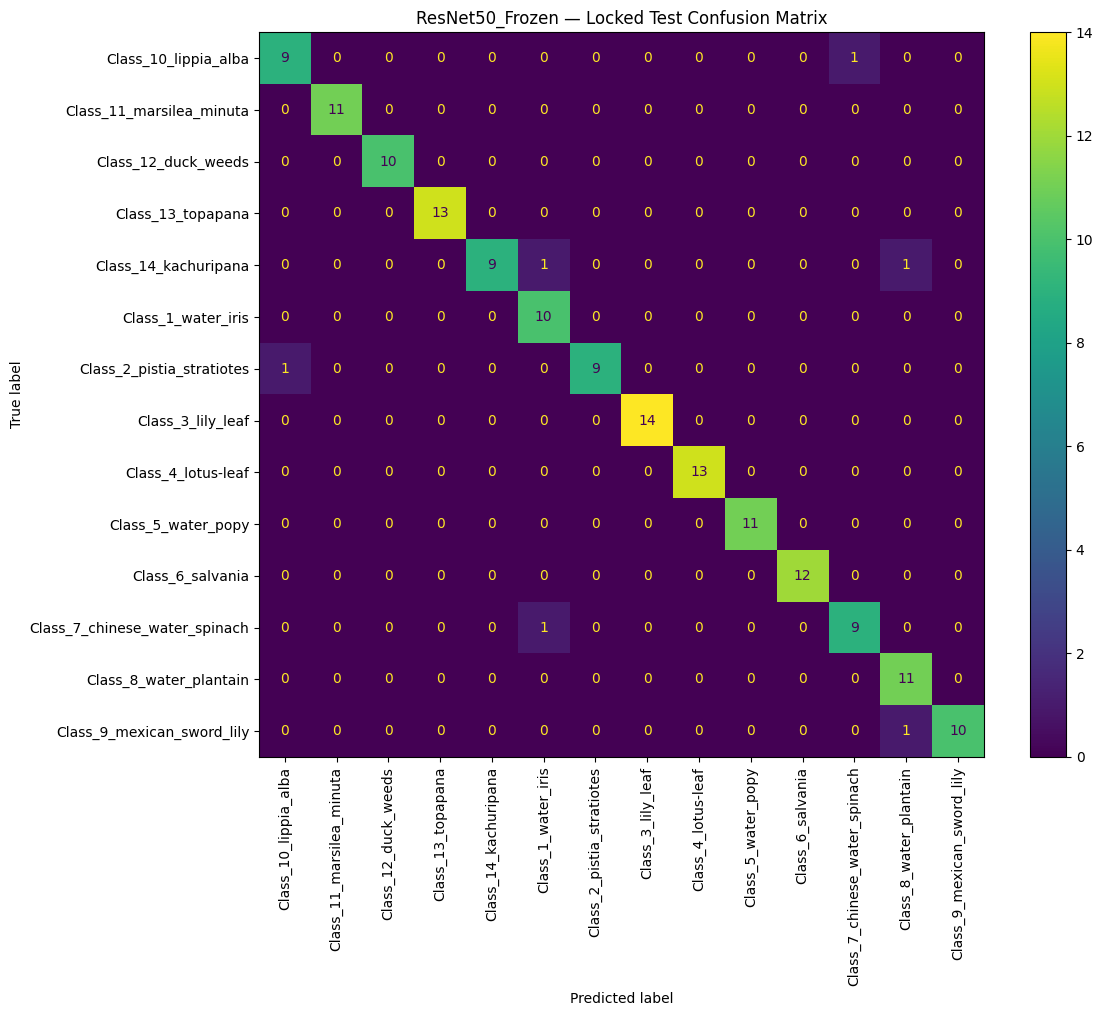

✅ Saved: /kaggle/working/ResNet50_Frozen_confusion_matrix.png


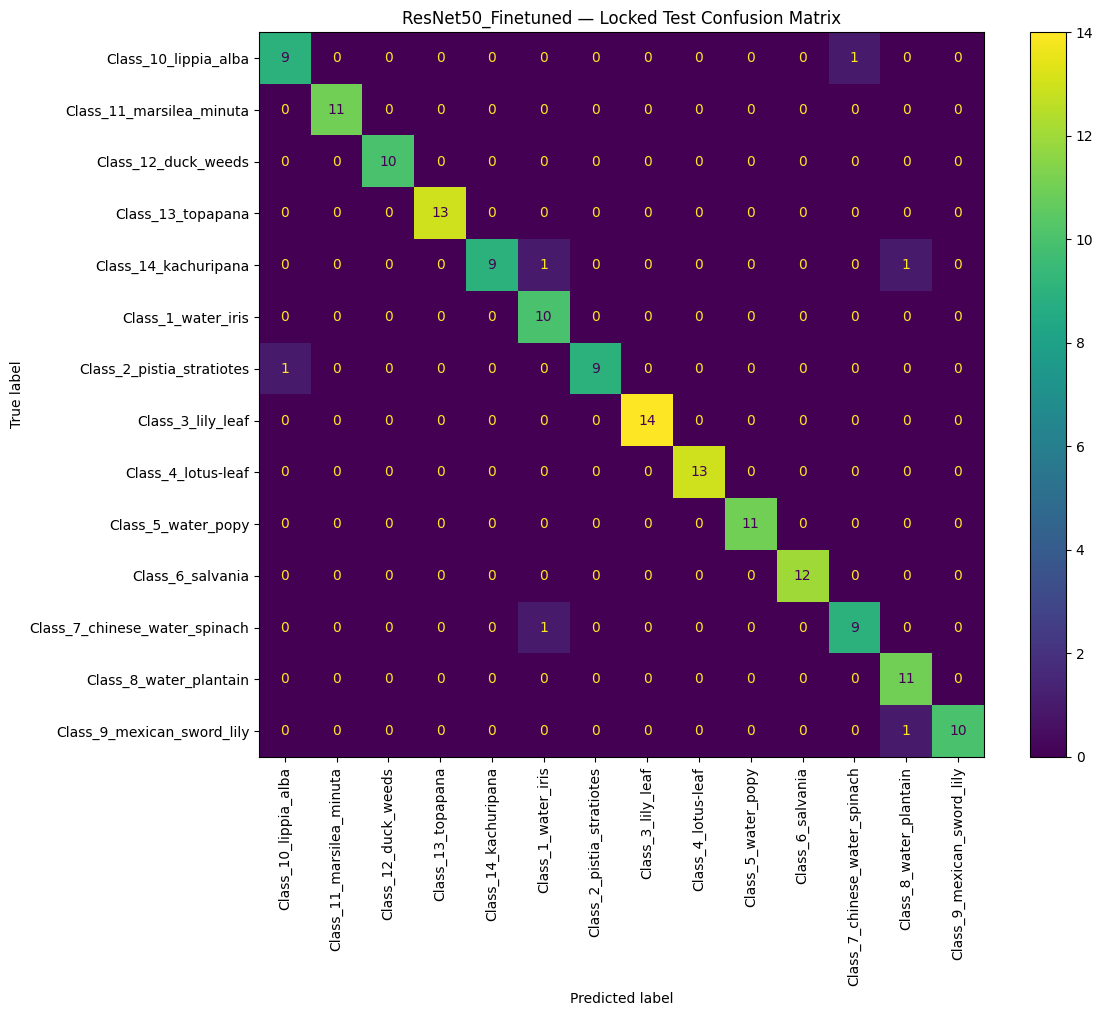

✅ Saved: /kaggle/working/ResNet50_Finetuned_confusion_matrix.png


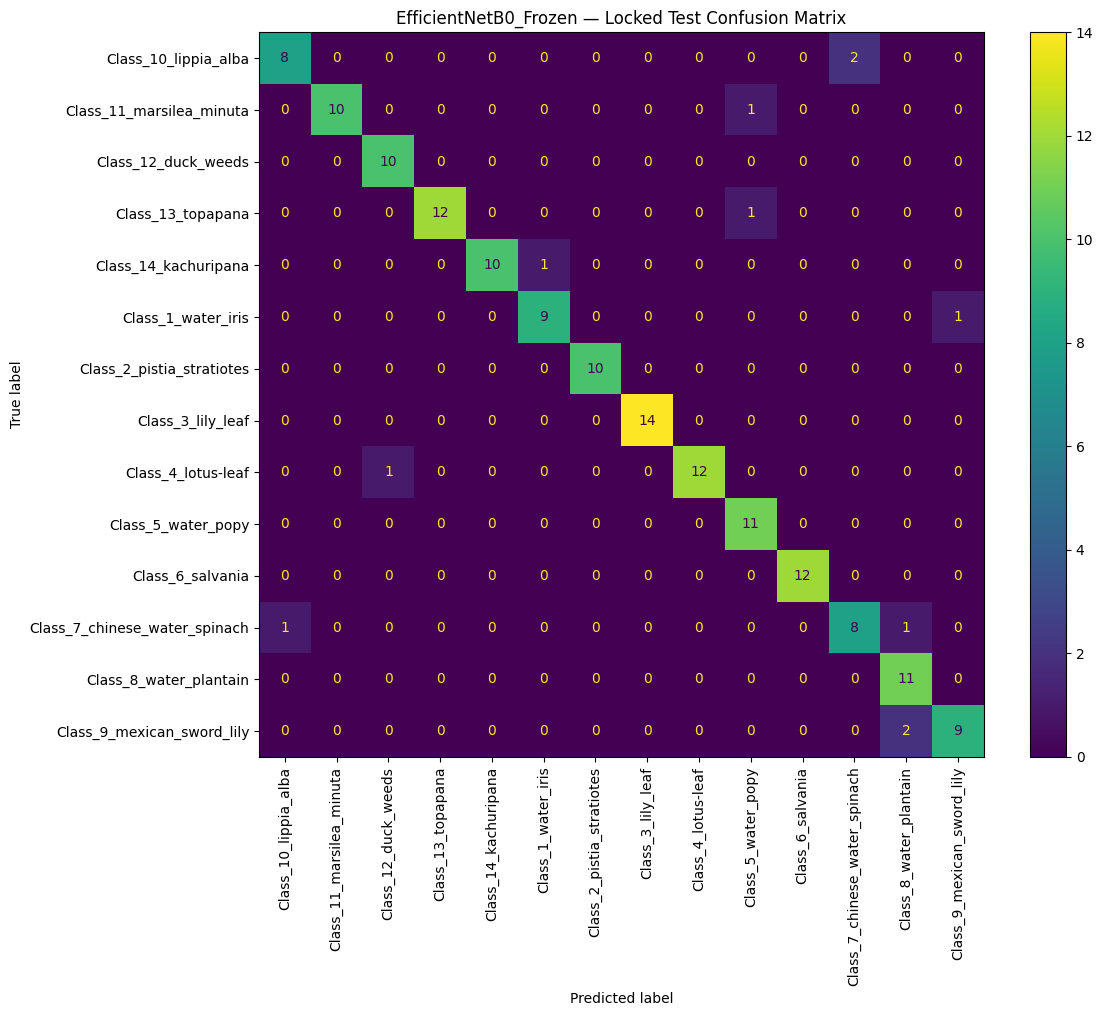

✅ Saved: /kaggle/working/EfficientNetB0_Frozen_confusion_matrix.png


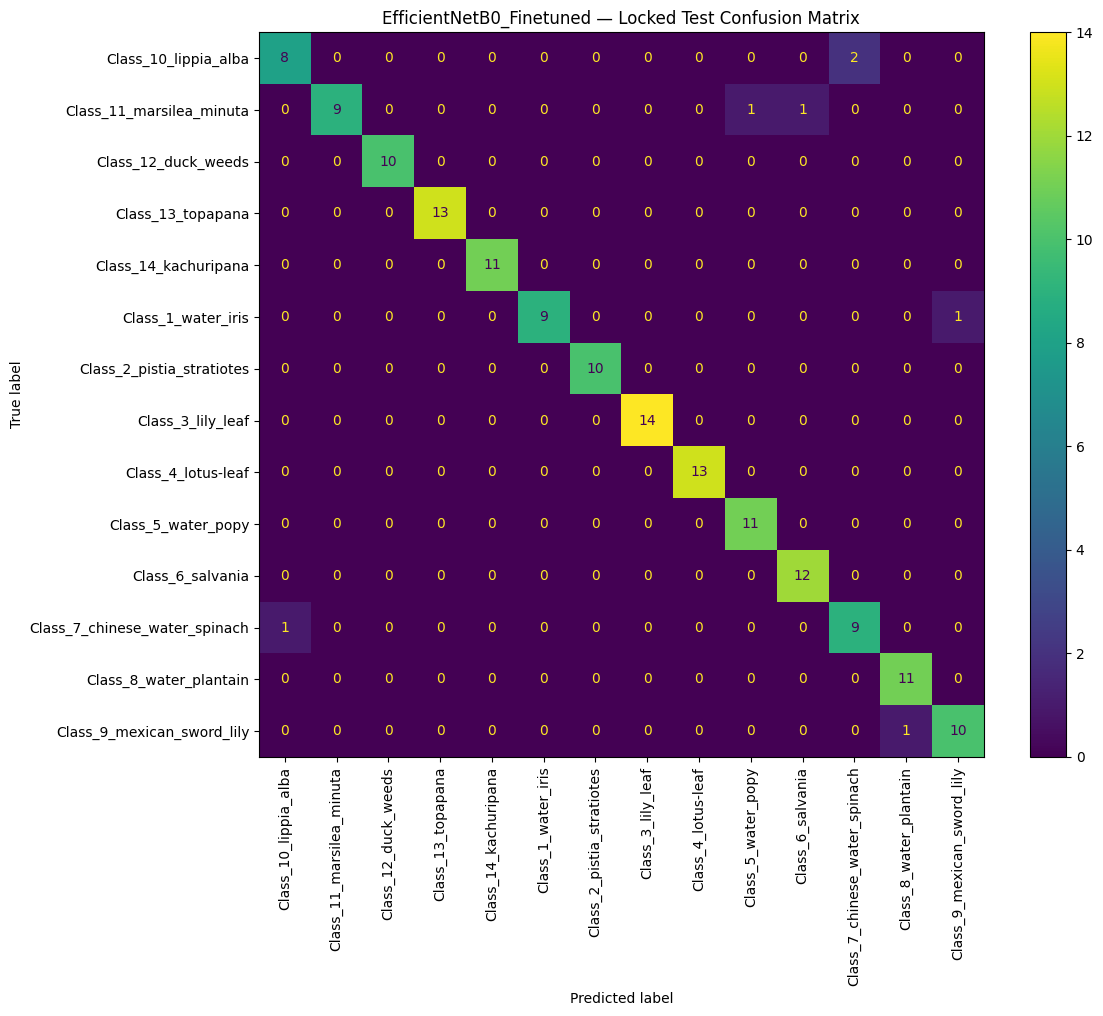

✅ Saved: /kaggle/working/EfficientNetB0_Finetuned_confusion_matrix.png


In [30]:
# ============================================================
# CELL 12 — CONFUSION MATRICES
# ============================================================

for name, result in results.items():
    cm = confusion_matrix(
        result["y_true"],
        result["y_pred"]
    )

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=True
    )

    ax.set_title(
        f"{name} — Locked Test Confusion Matrix"
    )

    plt.tight_layout()

    save_path = (
        f"/kaggle/working/"
        f"{name}_confusion_matrix.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ Saved:", save_path)


In [31]:
# ============================================================
# CELL 13 — SAVE IMAGE-LEVEL PREDICTIONS + RAW PROBABILITIES
# Useful for later calibration / selective prediction / errors
# ============================================================

sample_paths = [
    path
    for path, label in test_dataset.samples
]

for name, result in results.items():
    pred_df = pd.DataFrame({
        "image_path": sample_paths,
        "true_index": result["y_true"],
        "true_class": [
            CLASS_NAMES[i]
            for i in result["y_true"]
        ],
        "pred_index": result["y_pred"],
        "pred_class": [
            CLASS_NAMES[i]
            for i in result["y_pred"]
        ],
        "confidence": result["confidence"],
        "correct": (
            result["y_true"]
            == result["y_pred"]
        ),
    })

    pred_path = (
        f"/kaggle/working/"
        f"{name}_test_predictions.csv"
    )

    pred_df.to_csv(
        pred_path,
        index=False
    )

    # Save raw probabilities losslessly.
    prob_path = (
        f"/kaggle/working/"
        f"{name}_test_probabilities.npz"
    )

    np.savez_compressed(
        prob_path,
        y_true=result["y_true"],
        y_pred=result["y_pred"],
        y_prob=result["y_prob"],
        confidence=result["confidence"],
        image_paths=np.asarray(sample_paths),
        class_names=np.asarray(CLASS_NAMES),
    )

    print(name)
    print("  ✅ Predictions:", pred_path)
    print("  ✅ Probabilities:", prob_path)

print("\n✅ Image-level outputs saved.")


ResNet50_Frozen
  ✅ Predictions: /kaggle/working/ResNet50_Frozen_test_predictions.csv
  ✅ Probabilities: /kaggle/working/ResNet50_Frozen_test_probabilities.npz
ResNet50_Finetuned
  ✅ Predictions: /kaggle/working/ResNet50_Finetuned_test_predictions.csv
  ✅ Probabilities: /kaggle/working/ResNet50_Finetuned_test_probabilities.npz
EfficientNetB0_Frozen
  ✅ Predictions: /kaggle/working/EfficientNetB0_Frozen_test_predictions.csv
  ✅ Probabilities: /kaggle/working/EfficientNetB0_Frozen_test_probabilities.npz
EfficientNetB0_Finetuned
  ✅ Predictions: /kaggle/working/EfficientNetB0_Finetuned_test_predictions.csv
  ✅ Probabilities: /kaggle/working/EfficientNetB0_Finetuned_test_probabilities.npz

✅ Image-level outputs saved.


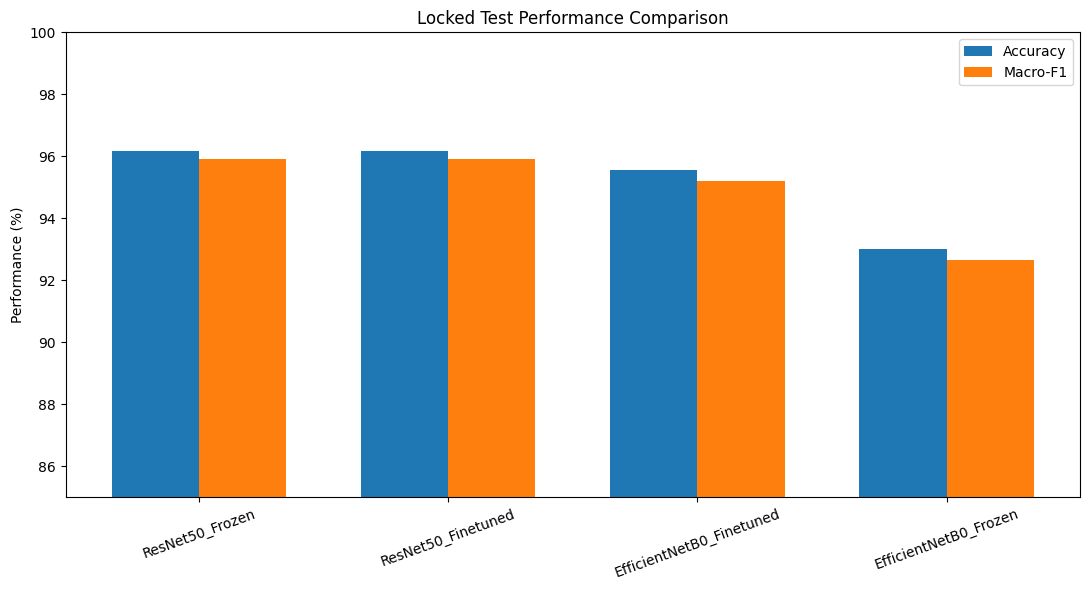

✅ Saved: /kaggle/working/phaseD_clean_test_comparison.png


In [32]:
# ============================================================
# CELL 14 — CLEAN TEST COMPARISON FIGURE
# ============================================================

plot_df = summary_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    plot_df["Test Accuracy (%)"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    plot_df["Macro-F1 (%)"],
    width,
    label="Macro-F1"
)

plt.xticks(
    x,
    plot_df["Model"],
    rotation=20
)

plt.ylabel("Performance (%)")
plt.title("Locked Test Performance Comparison")
plt.ylim(85, 100)
plt.legend()
plt.tight_layout()

comparison_plot = (
    "/kaggle/working/"
    "phaseD_clean_test_comparison.png"
)

plt.savefig(
    comparison_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", comparison_plot)


In [33]:
# ============================================================
# CELL 15 — FROZEN VS FINE-TUNED ABLATION
# ============================================================

ablation_rows = []

for architecture in [
    "ResNet50",
    "EfficientNetB0"
]:
    frozen_name = f"{architecture}_Frozen"
    fine_name = f"{architecture}_Finetuned"

    frozen = results[frozen_name]
    fine = results[fine_name]

    ablation_rows.append({
        "Architecture": architecture,
        "Frozen Accuracy (%)": frozen["accuracy"] * 100,
        "Fine-tuned Accuracy (%)": fine["accuracy"] * 100,
        "Accuracy Change (pp)": (
            fine["accuracy"] - frozen["accuracy"]
        ) * 100,
        "Frozen Macro-F1 (%)": frozen["macro_f1"] * 100,
        "Fine-tuned Macro-F1 (%)": fine["macro_f1"] * 100,
        "Macro-F1 Change (pp)": (
            fine["macro_f1"] - frozen["macro_f1"]
        ) * 100,
    })

ablation_df = pd.DataFrame(ablation_rows)

display(ablation_df.round(4))

ablation_path = (
    "/kaggle/working/"
    "phaseD_finetuning_ablation.csv"
)

ablation_df.to_csv(
    ablation_path,
    index=False
)

print("\n✅ Saved:", ablation_path)


,Architecture,Frozen Accuracy (%),Fine-tuned Accuracy (%),Accuracy Change (pp),Frozen Macro-F1 (%),Fine-tuned Macro-F1 (%),Macro-F1 Change (pp)
0,ResNet50,96.1783,96.1783,0.0000,95.8965,95.8965,0.0000
1,EfficientNetB0,92.9936,95.5414,2.5478,92.6647,95.2054,2.5407



✅ Saved: /kaggle/working/phaseD_finetuning_ablation.csv


In [34]:
# ============================================================
# CELL 16 — MOST COMMON ERROR PAIRS
# Fine-tuned models only
# ============================================================

for name in [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned",
]:
    r = results[name]

    cm = confusion_matrix(
        r["y_true"],
        r["y_pred"]
    )

    confusion_list = []

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm[i, j] > 0:
                confusion_list.append({
                    "True Class": CLASS_NAMES[i],
                    "Predicted Class": CLASS_NAMES[j],
                    "Count": int(cm[i, j]),
                })

    confusion_df = pd.DataFrame(confusion_list)

    if len(confusion_df) > 0:
        confusion_df = (
            confusion_df
            .sort_values(
                "Count",
                ascending=False
            )
            .reset_index(drop=True)
        )

    print("\n" + "=" * 72)
    print(name, "— MOST COMMON ERRORS")
    print("=" * 72)

    display(confusion_df.head(15))

    save_path = (
        f"/kaggle/working/"
        f"{name}_confusion_pairs.csv"
    )

    confusion_df.to_csv(
        save_path,
        index=False
    )

    print("✅ Saved:", save_path)



ResNet50_Finetuned — MOST COMMON ERRORS


,True Class,Predicted Class,Count
0,Class_10_lippia_alba,Class_7_chinese_water_spinach,1
1,Class_14_kachuripana,Class_1_water_iris,1
2,Class_14_kachuripana,Class_8_water_plantain,1
3,Class_2_pistia_stratiotes,Class_10_lippia_alba,1
4,Class_7_chinese_water_spinach,Class_1_water_iris,1
5,Class_9_mexican_sword_lily,Class_8_water_plantain,1


✅ Saved: /kaggle/working/ResNet50_Finetuned_confusion_pairs.csv

EfficientNetB0_Finetuned — MOST COMMON ERRORS


,True Class,Predicted Class,Count
0,Class_10_lippia_alba,Class_7_chinese_water_spinach,2
1,Class_11_marsilea_minuta,Class_5_water_popy,1
2,Class_11_marsilea_minuta,Class_6_salvania,1
3,Class_1_water_iris,Class_9_mexican_sword_lily,1
4,Class_7_chinese_water_spinach,Class_10_lippia_alba,1
5,Class_9_mexican_sword_lily,Class_8_water_plantain,1


✅ Saved: /kaggle/working/EfficientNetB0_Finetuned_confusion_pairs.csv


In [35]:
# ============================================================
# CELL 17 — PHASE D METADATA
# ============================================================

metadata = {
    "phase": "Phase D — Locked Test Evaluation",
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "test_images": len(test_dataset),
    "test_directory": TEST_DIR,
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "models_evaluated": list(models.keys()),
    "training_or_tuning_performed": False,
}

metadata_path = (
    "/kaggle/working/"
    "phaseD_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print(json.dumps(metadata, indent=2))
print("\n✅ Saved:", metadata_path)


{
  "phase": "Phase D \u2014 Locked Test Evaluation",
  "seed": 42,
  "image_size": 224,
  "batch_size": 32,
  "num_classes": 14,
  "test_images": 157,
  "test_directory": "/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test",
  "device": "cuda",
  "gpu": "Tesla T4",
  "models_evaluated": [
    "ResNet50_Frozen",
    "ResNet50_Finetuned",
    "EfficientNetB0_Frozen",
    "EfficientNetB0_Finetuned"
  ],
  "training_or_tuning_performed": false
}

✅ Saved: /kaggle/working/phaseD_metadata.json


In [36]:
# ============================================================
# CELL 18 — CREATE COMPLETE PHASE-D BACKUP ZIP
# ============================================================

PHASE_D_ZIP = (
    "/kaggle/working/"
    "AquaPlant_PhaseD_Locked_Test_Artifacts.zip"
)

allowed_extensions = (
    ".csv",
    ".png",
    ".npz",
    ".json",
)

files_to_backup = []

for file in os.listdir("/kaggle/working"):
    full_path = os.path.join(
        "/kaggle/working",
        file
    )

    if (
        os.path.isfile(full_path)
        and file.lower().endswith(allowed_extensions)
    ):
        files_to_backup.append(full_path)

with zipfile.ZipFile(
    PHASE_D_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for file in files_to_backup:
        zipf.write(
            file,
            arcname=os.path.basename(file)
        )

print("=" * 72)
print("PHASE D BACKUP")
print("=" * 72)

print("ZIP  :", PHASE_D_ZIP)
print("Files:", len(files_to_backup))
print(
    "Size :",
    f"{os.path.getsize(PHASE_D_ZIP) / (1024 ** 2):.2f} MB"
)

print("\nIncluded files:")
for file in sorted(files_to_backup):
    print(" -", os.path.basename(file))

print("\n✅ PHASE D COMPLETE")
print("✅ Download AquaPlant_PhaseD_Locked_Test_Artifacts.zip")


PHASE D BACKUP
ZIP  : /kaggle/working/AquaPlant_PhaseD_Locked_Test_Artifacts.zip
Files: 23
Size : 1.55 MB

Included files:
 - EfficientNetB0_Finetuned_classwise_metrics.csv
 - EfficientNetB0_Finetuned_confusion_matrix.png
 - EfficientNetB0_Finetuned_confusion_pairs.csv
 - EfficientNetB0_Finetuned_test_predictions.csv
 - EfficientNetB0_Finetuned_test_probabilities.npz
 - EfficientNetB0_Frozen_classwise_metrics.csv
 - EfficientNetB0_Frozen_confusion_matrix.png
 - EfficientNetB0_Frozen_test_predictions.csv
 - EfficientNetB0_Frozen_test_probabilities.npz
 - ResNet50_Finetuned_classwise_metrics.csv
 - ResNet50_Finetuned_confusion_matrix.png
 - ResNet50_Finetuned_confusion_pairs.csv
 - ResNet50_Finetuned_test_predictions.csv
 - ResNet50_Finetuned_test_probabilities.npz
 - ResNet50_Frozen_classwise_metrics.csv
 - ResNet50_Frozen_confusion_matrix.png
 - ResNet50_Frozen_test_predictions.csv
 - ResNet50_Frozen_test_probabilities.npz
 - phaseD_class_mapping.json
 - phaseD_clean_test_comparison.pn

## After completion

Download:

`AquaPlant_PhaseD_Locked_Test_Artifacts.zip`

This ZIP contains the clean locked-Test summary, fine-tuning ablation, class-wise metrics, confusion matrices, image-level predictions, raw probability arrays, error-pair tables, and Phase-D metadata.

Do **not** retrain or tune any model after seeing the locked Test results.